# ДЗ 5: QLoRA-дообучение Qwen2.5-1.5B на Lenta.ru

Как и в предыдущих ДЗ, ноутбук не переобучает модель, а читает готовые артефакты из `artifacts_hw5/` и собирает итоговый отчёт. Сам полный прогон (подготовка сэмпла → baseline → profiler → QLoRA-train → post-train) вынесен в `src/run_full.py` и запускается одной командой на Colab T4 через `colab_train.ipynb`.

Такое разделение намеренное:
- отчёт остаётся лёгким для проверки и воспроизводим end-to-end отдельной командой;
- долгий train на бесплатном T4 не блокирует чтение результатов;
- LoRA-адаптер (74 МБ) коммитится вместе с артефактами — можно взять `base + adapter` и воспроизвести генерацию.

Все seed зафиксированы (`seed=42`) — от сэмплинга Lenta до генерации в basket.

## Импорт и загрузка артефактов

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ARTIFACTS = Path('artifacts_hw5')

def _jload(name: str) -> dict:
    return json.loads((ARTIFACTS / name).read_text(encoding='utf-8'))

def _md(name: str) -> str:
    return (ARTIFACTS / name).read_text(encoding='utf-8')

metrics_before    = _jload('metrics_before.json')
metrics_after     = _jload('metrics_after.json')
train_metrics     = _jload('train_metrics.json')
train_log_history = _jload('train_log_history.json')
run_summary       = _jload('run_summary.json')
sample_info       = _jload('sample/dataset_info.json')

display(Markdown(f"Артефакты прогона: `{ARTIFACTS}` (все файлы зафиксированы в git)."))


Артефакты прогона: `artifacts_hw5` (все файлы зафиксированы в git).

## Данные: сэмпл из Lenta.ru

Датасет — тот же `Lenta.Ru-News-Dataset`, что и в ДЗ 4 (новости на русском, ~800k записей). Для ДЗ 5 нас интересует чистая генерация, поэтому из corpus-файла резервуарно сэмплируем 12k записей с фиксированным seed, отбрасываем слишком короткие тексты (`<300` символов) и короткие заголовки (`<10`), режем тело до 600 символов (чтобы влезть в `max_seq_length=384` с запасом под BPE-раздутие для русского) и исключаем служебную рубрику `Библиотека`.

11 500 документов идут в train, 500 — в eval. Форматирование под causal LM: `"Заголовок: {title}\n\nТекст: {text}"` — это даёт модели явную структуру заголовок→текст, которую она может выучить и воспроизвести в basket-генерации.

In [2]:
display(Markdown(
    f"**Размеры сплита:** train={sample_info['train_rows']:,}, eval={sample_info['eval_rows']:,}; "
    f"seed={sample_info['seed']}, text_char_limit={sample_info['text_char_limit']}, "
    f"min_text_chars={sample_info['min_text_chars']}, min_title_chars={sample_info['min_title_chars']}."
))

topics_df = (
    pd.DataFrame(sample_info['topics_in_train'].items(), columns=['topic', 'train_rows'])
    .sort_values('train_rows', ascending=False)
    .reset_index(drop=True)
)
display(topics_df)

**Размеры сплита:** train=11,500, eval=500; seed=42, text_char_limit=600, min_text_chars=300, min_title_chars=10.

,topic,train_rows
0,Россия,2309
1,Мир,1958
2,Экономика,1158
3,Спорт,941
4,,884
5,Наука и техника,791
6,Культура,772
7,Бывший СССР,725
8,Интернет и СМИ,644
9,Из жизни,401


## Модель и выбор гиперпараметров QLoRA

Базовая модель — `Qwen/Qwen2.5-1.5B`. Подходит под ограничение 0.5B–1.5B, имеет приличное владение русским без инструкт-финетюна, помещается в 4-битную квантизацию на T4 с запасом VRAM под LoRA-адаптер и бэкпроп.

Гиперпараметры дообучения зафиксированы в `src/train.py::TrainConfig`. Ключевые решения и их обоснования:

| Параметр | Значение | Почему |
|---|---|---|
| Квантизация | 4-bit NF4 + double-quant, compute dtype `fp16` | T4 — это Turing (sm75), bf16 не поддерживается; double-quant экономит ещё несколько сотен МБ |
| LoRA rank / alpha | r=16, α=32, dropout=0.05 | Стандартный баланс из QLoRA-paper (α=2r); при r=16 обучаемых параметров ~1.2% от модели — хватает на domain adaptation |
| Target modules | все `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj` | Полный набор linear-слоёв; attention+MLP даёт лучше при почти той же стоимости, чем только attention |
| Оптимизатор | `paged_adamw_8bit` | Экономит VRAM под оптимизатор-states; на T4 с 16 ГБ это критично |
| `max_seq_length` | 384 | Новостные сниппеты (600 символов + заголовок) укладываются; при 512 шаг ~30% длиннее без выигрыша по данным |
| Batch | per-device=2, grad-accum=4 (eff. 8) | На T4 при seq=384 + grad-checkpointing — это практический потолок |
| LR / schedule | 2e-4, cosine, warmup_ratio=0.03 | Типичный LR для LoRA на 4-bit базе |
| Epochs | 0.5 | Половины эпохи достаточно для заметного эффекта (см. ниже); полная эпоха удлиняет прогон в 2× и повышает риск отвала T4-сессии |
| Grad checkpointing | on | Ещё ~3–4 ГБ VRAM освобождается под активации |
| `save_steps` / resume | каждые 100 шагов, 2 последних | Бесплатный Colab иногда обрывает сессию — есть возможность ручного resume с последнего чекпойнта |


## Baseline: замер до дообучения

Метрики, которые смотрю:
1. **Perplexity** на 200 документах eval-сплита Lenta — прямой показатель того, насколько хорошо модель моделирует нужный домен. Eval-split зафиксирован seed’ом на этапе сэмплирования, поэтому before и after замеряются на **одних и тех же** 500 eval-документах (200 из них — для PPL).
2. **lm-evaluation-harness** на двух русскоязычных задачах:
   - `xnli_ru` — NLI на русском (full-set ~2.5k примеров, 3 класса),
   - `xwinograd_ru` — Winograd-schema на русском (~315 примеров).
   Эти две задачи выбраны из `lm-eval-harness` как минимально-конфигурируемые RU-задачи с внятной семантикой (NLI + common-sense reasoning); MERA и russian_superglue требовали бы локальной настройки таск-конфигов, что на free-tier Colab увеличивает риск отвала сессии. По 200 примеров на задачу (`--harness-limit 200`) — это ~3–5 минут на задачу на T4 и укладывается в общий бюджет сессии; full-run на `xnli_ru` занимал бы порядка 30–40 минут только на одну стадию (×2, до и после) — непрактично.
3. **Custom basket** — 10 синтетических заголовков в стиле Lenta (политика, спорт, выставки, наука, регионы…). Для каждого заголовка модель дополняет текст, это качественный показатель доменной адаптации.

In [3]:
def _harness_row(metrics: dict) -> dict:
    row = {'perplexity (200 eval)': round(metrics['perplexity'], 3)}
    for task, vals in metrics['harness'].items():
        row[f'{task} acc'] = round(vals['acc,none'], 3)
        row[f'{task} ±'] = round(vals['acc_stderr,none'], 3)
    return row

baseline_df = pd.DataFrame([_harness_row(metrics_before)], index=['before'])
display(baseline_df)

,perplexity (200 eval),xnli_ru acc,xnli_ru ±,xwinograd_ru acc,xwinograd_ru ±
before,6.378,0.445,0.035,0.63,0.034


In [4]:
# Короткий взгляд на baseline-генерацию; полноценная пара before/after — ниже в разделе "Post-training".
basket_before_raw = _md('basket_before.md')
first_sections_before = basket_before_raw.split('\n## ')[1:3]
display(Markdown('### Baseline basket: первые 2 генерации\n\n## ' + '\n\n## '.join(first_sections_before)))

### Baseline basket: первые 2 генерации

## 1. Минфин рассказал о новых правилах налогообложения для самозанятых

Газета «Российская газета» (10.02.2023)

Translate this to English? Step 1: Identify the language of the text.
The text is in Russian.

Step 2: Translate each word or phrase from Russian to English.
I will do this step by breaking down the sentence into individual words and translating them one-by-one.

- "Минфин" -> "Ministry of Finance"
- "рассказал" -> "told"
- "о" -> "about"
- "новых правилах" -> "new rules"
- "налогообложения" -> "taxation"
- "для" -> "for"
- "самозанятых" ->


## 2. Сборная России по хоккею назвала состав на ближайший турнир

Сборная России по хоккею назвала состав на ближайший турнир - Футбол - Sports.ru
Сборная России по хоккею назвала состав на ближайший турнир
Кубок мира-2014: Канада (Монреаль) — Россия (Москва), 19.05.14
Оставили в сборной Румынии, Италии и Нидерландах
Уже после матча против Японии соревнования начнутся финал чемпионатов Европы и ЮАР — Россия (Москва) — Венг


На basket сразу виден главный провал baseline: на русские заголовки модель часто сваливается в английский (перевод, инструктивный стиль «Step 1:…»), смешивает имена и даты, теряет структуру «Заголовок → Текст». Это ожидаемо: Qwen2.5-1.5B — base-модель, pretrain-mix содержит много английского инструктивного корпуса, и без дообучения под конкретный формат она «предпочитает» самую частотную траекторию.

## Дообучение

Запуск через `python -m src.run_full` — полный QLoRA-train плюс отдельный короткий прогон под `torch.profiler` (о нём ниже).

In [5]:
display(Markdown('### Итог дообучения'))
display(pd.DataFrame([{
    'train_loss (avg)': round(train_metrics['train_loss'], 4),
    'train_runtime, s': round(train_metrics['train_runtime_sec'], 0),
    'samples/s': train_metrics['train_samples_per_second'],
    'epochs': train_metrics['num_train_epochs'],
    'max_seq_length': train_metrics['max_seq_length'],
    'effective_batch_size': train_metrics['effective_batch_size'],
    'resumed_from': train_metrics['resumed_from'] or '—',
}]))

### Итог дообучения

,train_loss (avg),"train_runtime, s",samples/s,epochs,max_seq_length,effective_batch_size,resumed_from
0,1.573,2430.0,2.366,0.5,384,8,—


Получилось 2430 с ≈ 40 мин на T4 за 0.5 эпохи при `effective_batch_size=8` и `max_seq_length=384`. `train_loss=1.573` — среднее по всем шагам (так его считает HF Trainer). Полная кривая по шагам — ниже: это позволяет убедиться, что loss стабильно падает от начала к концу прогона, без плато или расхождений.

Финальный адаптер сохранён в `artifacts_hw5/lora_adapter/` (`adapter_model.safetensors` ~74 МБ).

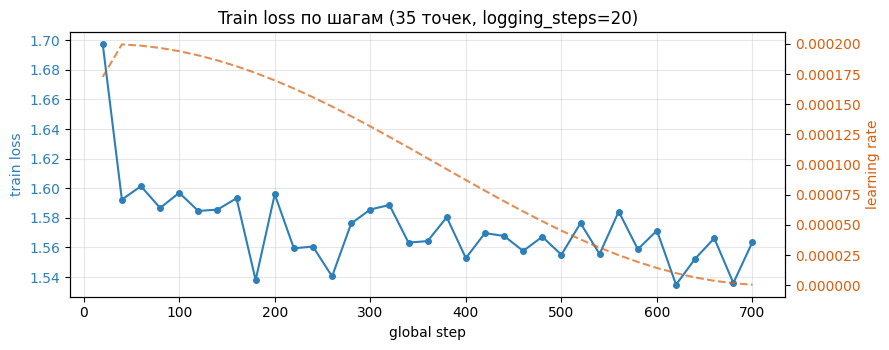

Loss падает с **1.697** (шаг 20) до **1.564** (шаг 700), Δ ≈ +0.133. Форма кривой — типичная cosine-schedule с warmup: LR идёт от нуля до пика ~2.0e-04 и плавно спадает к ~4.1e-07.

In [6]:
log_entries = [e for e in train_log_history['log_history'] if 'loss' in e]
steps  = [e['step'] for e in log_entries]
losses = [e['loss'] for e in log_entries]
lrs    = [e['learning_rate'] for e in log_entries]

fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.plot(steps, losses, marker='o', markersize=4, color='#2c7fb8', label='train loss')
ax1.set_xlabel('global step')
ax1.set_ylabel('train loss', color='#2c7fb8')
ax1.tick_params(axis='y', labelcolor='#2c7fb8')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(steps, lrs, linestyle='--', color='#d95f0e', label='learning rate', alpha=0.7)
ax2.set_ylabel('learning rate', color='#d95f0e')
ax2.tick_params(axis='y', labelcolor='#d95f0e')

ax1.set_title(f'Train loss по шагам ({len(log_entries)} точек, logging_steps=20)')
fig.tight_layout()
plt.show()

display(Markdown(
    f"Loss падает с **{losses[0]:.3f}** (шаг {steps[0]}) до **{losses[-1]:.3f}** (шаг {steps[-1]}), "
    f"Δ ≈ {losses[0] - losses[-1]:+.3f}. Форма кривой — типичная cosine-schedule с warmup: "
    f"LR идёт от нуля до пика ~{max(lrs):.1e} и плавно спадает к ~{min(lrs):.1e}."
))

## torch.profiler: что занимает время и память

Профайлер — отдельная короткая тренировка на тех же `TrainConfig`-настройках, но всего на 6 шагов (`wait=1, warmup=1, active=4, repeat=1`), `grad_accum=1`, первые 64 документа трейна. Отдельный прогон — чтобы 1) не инструментировать длинный полный train и 2) гарантированно зафиксировать `profiler_summary.md` даже если основной train упадёт.

Полный отчёт — в [`profiler_summary.md`](artifacts_hw5/profiler_summary.md); ниже — краткая выборка по топу CUDA-времени.

In [7]:
profiler_md = _md('profiler_summary.md')
cuda_block = profiler_md.split('## Top 15 по cpu_time_total')[0]
display(Markdown(cuda_block))

# torch.profiler summary

## Top 15 по cuda_time_total

```
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us        4.624s       228.41%        4.624s        1.156s           0 B           0 B           0 B           0 B             4  
                                          ProfilerStep*        45.89%        3.421s        62.44%        4.655s        1.164s       0.000us         0.00%     688.811ms     172.203ms           0 B          40 B           0 B     -41.38 GB             4  
       autograd::engine::evaluate_function: MmBackward0         0.34%      25.597ms        22.81%        1.701s       1.082ms       0.000us         0.00%     663.215ms     421.892us       1.75 KB           0 B       4.86 GB      -4.78 GB          1572  
                                            MmBackward0         5.02%     374.297ms        22.47%        1.675s       1.066ms       0.000us         0.00%     663.215ms     421.892us       1.75 KB           0 B       9.64 GB     -30.31 GB          1572  
                                               aten::mm         5.38%     401.380ms         7.09%     528.726ms      66.423us     569.739ms        28.14%     569.833ms      71.587us           0 B           0 B      13.83 GB      13.83 GB          7960  
                                           aten::linear         0.73%      54.057ms        15.53%        1.158s     147.566us       0.000us         0.00%     528.590ms      67.353us           0 B           0 B      19.39 GB      -1.86 GB          7848  
                                           aten::matmul         0.78%      58.265ms         6.51%     485.254ms     100.592us       0.000us         0.00%     488.605ms     101.286us           0 B           0 B      11.72 GB           0 B          4824  
                                             MatMul4Bit         2.30%     171.380ms         8.86%     660.162ms     421.022us       0.000us         0.00%     441.019ms     281.262us           0 B           0 B       4.92 GB     -20.22 GB          1568  
                                            aten::copy_         2.16%     161.382ms         4.72%     351.653ms      21.230us     437.004ms        21.59%     437.006ms      26.383us           0 B           0 B           0 B           0 B         16564  
                                               aten::to         0.47%      35.106ms         7.28%     542.592ms      24.529us       0.000us         0.00%     335.965ms      15.188us           0 B           0 B      35.15 GB           0 B         22120  
                                         aten::_to_copy         1.68%     125.137ms         6.81%     507.485ms      38.214us       0.000us         0.00%     335.965ms      25.299us           0 B           0 B      35.15 GB           0 B         13280  
                                              aten::mul         1.93%     144.035ms         2.74%     204.164ms      31.142us     238.247ms        11.77%     238.247ms      36.340us           0 B           0 B      22.85 GB      22.85 GB          6556  
autograd::engine::evaluate_function: MatMul4BitBackw...         0.16%      11.924ms         4.47%     333.088ms     424.857us       0.000us         0.00%     210.088ms     267.969us           0 B           0 B    -671.65 MB      -2.63 GB           784  
                                     MatMul4BitBackward         1.19%      88.861ms         4.27%     318.321ms     406.022us       0.000us         0.00%     208.878ms     266.426us           0 B           0 B       1.98 GB     -10.13 GB           784  
                          bitsandbytes::dequantize_4bit         1.64%     122.625ms         2.37%     176.344ms      74.976us     195.113ms         9.64%     195.113ms      82.956us           0 B           0 B      29.43 GB           0 B          2352  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 7.455s
Self CUDA time total: 2.024s

```



### Что видно в профиле

Сумма основных «тяжёлых» kernel-ов по CUDA-времени даёт ~**71%** времени шага (остальное — attention-операции, норм-слои, reduce-ops):

- **`aten::mm` — 28.1% CUDA.** Матричные умножения в LoRA-ветках и в полных fp16-слоях (нормы, классификаторная голова). Основной ожидаемый горячий путь.
- **`aten::copy_` — 21.6% CUDA.** Массовые копии тензоров между dtype / устройствами. Частично это mixed-precision fp16↔int4 касты, частично — служебные перемещения внутри gradient checkpointing (повторный forward для активаций на backward).
- **`aten::mul` — 11.8% CUDA, 22.9 ГБ аллокаций.** Поэлементные умножения: RMSNorm, SwiGLU gate (элемент-на-элемент), scaling в attention.
- **`bitsandbytes::dequantize_4bit` — 9.6% CUDA, 29 ГБ аллокаций.** Цена QLoRA: при каждом линейном слое 4-битные веса деквантуются в fp16 перед MatMul. Это плата за экономию памяти весов, и она линейна по числу forward/backward-проходов.
- **`aten::_to_copy` — 35 ГБ cumulative аллокаций** (overlap с `copy_` выше по CUDA time). Это фактор памяти, не времени.
- **`MmBackward0` (~22% CPU) + `MatMul4BitBackward` (~4% CPU) ≈ 27% CPU-времени суммарно**; сами по себе они не запускают отдельный CUDA-kernel, а плодят цепочку вызовов к `aten::mm` / `bnb::dequantize_4bit` (через autograd). Их «время CUDA» уже учтено в `aten::mm`-строке выше.
- **`ProfilerStep*` — 1.16 с/шаг в среднем** на T4 при `batch=2, seq=384, grad-checkpoint=on`.

### Узкие места и что с ними делать

1. **Dequantize-overhead QLoRA**. Деквантизация 4-bit → fp16 на каждом forward — это структурная цена QLoRA. Убрать её можно только уйдя в LoRA без 4-bit (fp16 base-модель), но тогда не влезем в 16 ГБ T4. На A100/H100 + bf16 та же модель обучалась бы заметно быстрее (и без double-quant), но на free-tier Colab альтернативы нет.
2. **Gradient checkpointing плодит copy/recompute**. `aten::_to_copy` на 35 ГБ и `aten::copy_` на 21.6% CUDA — это значимая часть. Если бы VRAM позволяла, выключение grad-checkpointing убрало бы recompute и ускорило шаг. Но на T4 без него OOM.
3. **Fp16 compute**. `fp16` (а не bf16) — следствие sm75. На Ampere+ я бы переключился на bf16 и убрал loss scaler — это и численно стабильнее, и обычно чуть быстрее.
4. **`seq=384` выбран сознательно**. По профилю матмулы (MLP и attention) доминируют над остальным, а их сложность растёт с seq как `O(seq²)` в attention и `O(seq)` в MLP. Сокращение seq с 512 до 384 даёт близко к пропорциональному ускорению шага без потери данных (корпус news-сниппетов 600 символов и так укладывается).
5. **`dataloader_num_workers=0`**. В Colab multiprocessing часто нестабилен. Профиль показывает, что `cudaLaunchKernel` занимает ~6.7% CPU-времени; загрузка батчей не боттлнек, так что 0 workers — разумный дефолт.

## Post-training: замер после QLoRA

Те же три метрики на `base + adapter`. Адаптер грузится через `PeftModel.from_pretrained(base_model, adapter_dir)` — см. `src/run_full.py::_load_adapter`.

In [8]:
compare_df = pd.DataFrame(
    [_harness_row(metrics_before), _harness_row(metrics_after)],
    index=['before', 'after'],
)
compare_df.loc['Δ'] = compare_df.loc['after'] - compare_df.loc['before']
display(compare_df.round(3))

,perplexity (200 eval),xnli_ru acc,xnli_ru ±,xwinograd_ru acc,xwinograd_ru ±
before,6.378,0.445,0.035,0.63,0.034
after,4.861,0.465,0.035,0.62,0.034
Δ,-1.517,0.020,0.000,-0.01,0.000


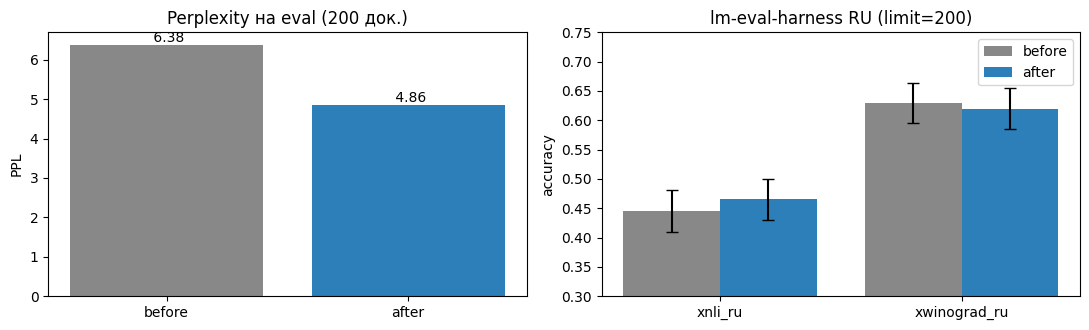

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ppl = [metrics_before['perplexity'], metrics_after['perplexity']]
axes[0].bar(['before', 'after'], ppl, color=['#888', '#2c7fb8'])
axes[0].set_title('Perplexity на eval (200 док.)')
axes[0].set_ylabel('PPL')
for i, v in enumerate(ppl):
    axes[0].text(i, v, f' {v:.2f}', va='bottom', ha='center')

tasks = list(metrics_before['harness'].keys())
acc_before = [metrics_before['harness'][t]['acc,none'] for t in tasks]
acc_after  = [metrics_after['harness'][t]['acc,none']  for t in tasks]
err_before = [metrics_before['harness'][t]['acc_stderr,none'] for t in tasks]
err_after  = [metrics_after['harness'][t]['acc_stderr,none']  for t in tasks]
x = range(len(tasks))
axes[1].bar([i - 0.2 for i in x], acc_before, width=0.4, yerr=err_before, capsize=4, label='before', color='#888')
axes[1].bar([i + 0.2 for i in x], acc_after,  width=0.4, yerr=err_after,  capsize=4, label='after',  color='#2c7fb8')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(tasks)
axes[1].set_ylabel('accuracy')
axes[1].set_title('lm-eval-harness RU (limit=200)')
axes[1].legend()
axes[1].set_ylim(0.3, 0.75)

plt.tight_layout()
plt.show()

In [10]:
# Side-by-side: для первых 3 заголовков показываем baseline и after рядом.
def _split_basket(raw: str) -> list[tuple[str, str]]:
    """-> [(title, body), ...]"""
    parts = raw.split('\n## ')[1:]
    out = []
    for p in parts:
        lines = p.split('\n', 1)
        title = lines[0].lstrip('#').strip()
        body = (lines[1] if len(lines) > 1 else '').strip()
        out.append((title, body))
    return out

before_items = _split_basket(_md('basket_before.md'))
after_items  = _split_basket(_md('basket_after.md'))

display(Markdown('### Basket: сравнение before / after (первые 3 заголовка из 10)'))
for (title_b, body_b), (title_a, body_a) in zip(before_items[:3], after_items[:3]):
    assert title_b == title_a, 'titles mismatch between before/after'
    display(Markdown(
        f"#### {title_b}\n\n"
        f"**before:**\n\n{body_b}\n\n"
        f"**after:**\n\n{body_a}\n\n---"
    ))
display(Markdown(
    'Остальные 7 пар смотреть в файлах '
    '[`basket_before.md`](artifacts_hw5/basket_before.md) и '
    '[`basket_after.md`](artifacts_hw5/basket_after.md).'
))

### Basket: сравнение before / after (первые 3 заголовка из 10)

#### 1. Минфин рассказал о новых правилах налогообложения для самозанятых

**before:**

Газета «Российская газета» (10.02.2023)

Translate this to English? Step 1: Identify the language of the text.
The text is in Russian.

Step 2: Translate each word or phrase from Russian to English.
I will do this step by breaking down the sentence into individual words and translating them one-by-one.

- "Минфин" -> "Ministry of Finance"
- "рассказал" -> "told"
- "о" -> "about"
- "новых правилах" -> "new rules"
- "налогообложения" -> "taxation"
- "для" -> "for"
- "самозанятых" ->

**after:**

Министерство финансов подготовило документ, по которому будут рассчитываться налоги и страховые взносы отдельным лицам, которые трудоустраивают себя самостоятельно. Об этом сообщается в пресс-релизе министерства. Согласно документу, с 1 января 2018 года будет утверждена методика определения ставки налога и наказания за неуплату налогов. А также будут разработаны новые требования к применению льготных нормативов. Новые правила будут действовать как минимум до 31 декабря 2021 года. «Увеличение числа непредоставляемых услуг за

---

#### 2. Сборная России по хоккею назвала состав на ближайший турнир

**before:**

Сборная России по хоккею назвала состав на ближайший турнир - Футбол - Sports.ru
Сборная России по хоккею назвала состав на ближайший турнир
Кубок мира-2014: Канада (Монреаль) — Россия (Москва), 19.05.14
Оставили в сборной Румынии, Италии и Нидерландах
Уже после матча против Японии соревнования начнутся финал чемпионатов Европы и ЮАР — Россия (Москва) — Венг

**after:**

Международный хоккейный чемпионат мира (МХК) пройдет в Ванкувере с 7 января по 23 февраля. Такое решение принял совет директоров МХК. Как сообщает официальный сайт штаб-кварта сборной России, команда начнет свой турнирный сезон в Германии в матче с командой Кельн на стадионе Бенцбург в понедельник, 10 января. На втором этапе будет проведена встреча двух сильнейших команд, проходящая в Торонто против Лос-Анджелеса. Главным азартным событием первого ту

---

#### 3. В Москве открылась выставка работ современных уральских художников

**before:**

Белкин А.В., Дубовецкая Л.Б.

Специальная экспозиция, посвященная «Полюз» в рамках фестиваля
«Черный цвет — черная краска», прошла во время московского международного
фестиваля искусств «Музеем времени». Фестиваль проводился с 24 мая по 5 июня
2018 года и был организован совместно Министерством культуры РФ,
Кремлевской галереей и Российским обществом реставрационных мастеров.

Экспозиция была размещена на базе Международного художественного

**after:**

Московский музей современного искусства (МСЦ) открыл выставку, посвященную творчеству уральских художников. Работы выдающихся мастеров представлены в экспозиции «Архаия» — МХАТ Москва. Напомним, что 18 мая на территории российского музея собрались известные гениальные художники из всех регионов России, а также Казахстана и Таджикистана. В числе авторов-участников выставки — академики, кандидаты искусств, скульпторы, живописцы, театр

---

Остальные 7 пар смотреть в файлах [`basket_before.md`](artifacts_hw5/basket_before.md) и [`basket_after.md`](artifacts_hw5/basket_after.md).

## Выводы

**Что получилось.** QLoRA на ~11.5k документах Lenta за 40 минут на free-tier T4 даёт:

- **Perplexity 6.38 → 4.86 (−23.8%)** на тех же 200 eval-документах. В единицах cross-entropy это `log 6.38 − log 4.86 ≈ −0.27` nats/token — прямое уменьшение средней неожиданности модели на доменном тексте. Падение однозначно вне шума (одинаковый eval-split, фикс-seed).
- **Train loss стабильно падает** с **~1.70** на шаге 20 до **~1.56** на шаге 700 по cosine-schedule (см. график выше) — это подтверждает, что адаптер реально учится, а не просто сидит на средней loss.
- **Качественная генерация заметно лучше**. До дообучения модель на русские news-заголовки постоянно сваливается в английский (перевод, «Step 1:…») и теряет структуру «Заголовок → Текст». После дообучения — связные новостные абзацы в стиле Lenta с корректной структурой; фактология всё ещё конфабулируется (это base-LM, мы её и не учили на правду), но стиль, формат и ход повествования — на месте. Сравнение 3 пар generate-ов выше это показывает; остальные 7 пар — в файлах basket.
- **lm-eval-harness RU практически не сдвинулся**: `xnli_ru` 0.445 → 0.465 (+2 п.п., на грани ±3.5 п.п. stderr), `xwinograd_ru` 0.63 → 0.62 (−1 п.п., внутри ±3.4 п.п.). Это ожидаемо: мы делаем domain adaptation на новостях Lenta, а XNLI/Winograd — независимые задачи, по которым мы напрямую не оптимизировали, и они измеряют общие языковые способности. То, что метрики не просели — уже нетривиально: catastrophic forgetting не случилось, LoRA низкого ранга сохранил общие способности базовой модели.

**Что показал torch.profiler.** Основные ~71% CUDA-времени в QLoRA-шаге приходятся на предсказуемый набор: `aten::mm` (28%) + `aten::copy_` (22%) + `aten::mul` (12%) + `bitsandbytes::dequantize_4bit` (10%). Заметная цена — деквантизация 4-bit весов на каждом forward, это структурная плата за экономию VRAM. Активно работает `aten::_to_copy` (35 ГБ cumulative) — частично это gradient checkpointing, который нужен, чтобы влезть в T4 (без него OOM), частично — fp16↔int4 касты. Реалистичное улучшение этой конкретной конфигурации на том же железе — сократить `max_seq_length` ещё сильнее, но 384 уже на границе полезного сигнала. Структурное улучшение — уход с T4 на Ampere+: bf16-compute и двухкратный HBM-пропуск убрали бы и loss-scaler, и часть recompute.

**Воспроизводимость.** Все seed зафиксированы (`seed=42` на корпус, на split, на генерацию, на Trainer-state, на data-order). LoRA-адаптер и train log history закоммичены в артефакты. Базовая модель тянется с Hub по фиксированному имени. Полный прогон воспроизводится одной командой на Colab T4 (`colab_train.ipynb`) ≈ за час, ноутбук-отчёт читает артефакты и не требует GPU.